# YOLO Object Detector From Scratch

A from-scratch implementation of a YOLO detector, trained on a small dataset of apples, bananas, and oranges. Working through the [original paper](https://paperswithcode.com/paper/you-only-look-once-unified-real-time-object) to figure out: the training pair (x, y) format, translating the loss from its mathematical formula into code, and implementing the model architecture itself.

Built with pytorch / pytorch-lightning.

In [1]:
# This library is needed to parse the annotations
! pip install xmltodict pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.0 MB/s eta 0:00:00


Download the data

In [2]:
!pip install -q gdown
!gdown 1GilO6U3f1XG1T-8kbZtV1bzht1K4IRiN -O data.zip
!unzip -q data.zip
!rm data.zip
!ls -l

Downloading...
From (original): https://drive.google.com/uc?id=1GilO6U3f1XG1T-8kbZtV1bzht1K4IRiN
From (redirected): https://drive.google.com/uc?id=1GilO6U3f1XG1T-8kbZtV1bzht1K4IRiN&confirm=t&uuid=2d4619b5-c52c-41c4-9bb0-0c3aac15b52f
To: /content/data.zip
100% 30.0M/30.0M [00:00<00:00, 35.9MB/s]
total 12
drwx------ 4 root root 4096 Nov 26  2022 data
drwxr-xr-x 3 root root 4096 Sep  5 00:36 __MACOSX
drwxr-xr-x 1 root root 4096 Aug 24 13:28 sample_data


Let's look at what one of the annotation files looks like

In [3]:
!cat data/train/apple_3.xml

<annotation>
	<folder>train</folder>
	<filename>apple_3.jpg</filename>
	<path>C:\tensorflow1\models\research\object_detection\images\train\apple_3.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>1000</width>
		<height>708</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>apple</name>
		<pose>Unspecified</pose>
		<truncated>1</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>584</xmin>
			<ymin>438</ymin>
			<xmax>867</xmax>
			<ymax>708</ymax>
		</bndbox>
	</object>
	<object>
		<name>apple</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>492</xmin>
			<ymin>141</ymin>
			<xmax>740</xmax>
			<ymax>394</ymax>
		</bndbox>
	</object>
	<object>
		<name>apple</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>176</xmin>
			<ymin>199</ymin>
			<xmax>490</xmax>
			<ymax>466</ymax>
		</bndbox>
	</object>
	<obj

## Dataset for YOLOv1

In [4]:
import os
import cv2
import json
import glob
import tqdm
import xmltodict

from IPython.core.display import struct

from typing import List

import pandas as pd
import numpy as np

import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl

import albumentations as A
import albumentations.pytorch

from PIL import Image

import matplotlib.pyplot as plt

from sklearn.metrics import auc

from collections import Counter

In [5]:
import warnings
warnings.filterwarnings("ignore")

Since using augmentations for training will help in this project, I'll use the `albumentations` library.

It's especially convenient since it can recompute bounding box coordinates automatically after image transforms. For an intro to this, see this [guide](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/).

`torchvision.transforms` is also an option -- it uses the familiar `__getitem__` method, but then bounding box coordinates need to be recomputed manually after each transform.

__Note__ that the paper parameterizes prediction boxes as _(x_center, y_center, width, height)_ (as relative values), while the annotation files here use _(x_min, y_min, x_max, y_max)_.

Also, the model needs to predict both the bounding box and the class probabilities!

In [6]:
class2tag = {"apple": 0, "orange": 1, "banana": 2}

class FruitDataset(Dataset):
    def __init__(self, data_dir, transforms=None, S=7, B=2, C=3):
        self.image_paths = [data_dir + '/' + image  for image in sorted(os.listdir(data_dir))
                        if image[-4:]=='.jpg']
        self.box_paths = [data_dir + '/' + image  for image in sorted(os.listdir(data_dir))
                        if image[-4:]=='.xml']

        assert len(self.image_paths) == len(self.box_paths)

        self.transforms = transforms
        self.S = S
        self.B = B
        self.C = C
    # Return the box coordinates in (x_center, y_center, width, height) format
    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        boxes, class_labels = self.__get_boxes_from_xml(self.box_paths[idx])
        if self.transforms:
            transformed = self.transforms(image = image, bboxes=boxes, class_labels = class_labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            class_labels = transformed['class_labels']
        target_tensor = torch.zeros((self.S, self.S, self.C + 5 * self.B))
        i = -1
        for box in boxes:
            i += 1
            class_label = class_labels[i]
            x, y, width, height = box[0], box[1], box[2], box[3]
            for elem in class2tag.keys():
                if elem == class_label:
                    class_label = class2tag[elem]

            i1, j1 = int(self.S * y), int(self.S * x)

            if target_tensor[i1, j1, self.C] == 0:

                target_tensor[i1, j1, self.C] = 1
                box_coordinates = torch.tensor(
                    [x, y, width, height]
                )

                target_tensor[i1, j1, 4:8] = box_coordinates


                target_tensor[i1, j1, class_label] = 1
        image = (image/255)
        return image, target_tensor

    def __len__(self):
        return len(self.image_paths)

    def __get_boxes_from_xml(self, xml_filename: str):
        boxes = []
        class_labels = []
        img = cv2.imread(xml_filename[:-3] + 'jpg')
        im_h = int(img.shape[0])
        im_w = int(img.shape[1])
        fileptr = open(xml_filename,"r")
        xml_content= fileptr.read()
        my_ordered_dict=xmltodict.parse(xml_content)['annotation']
        if type(my_ordered_dict['object']) is list:
            for i in range(len(my_ordered_dict['object'])):
                class_labels.append(my_ordered_dict['object'][i]['name'])
                xmin = int(my_ordered_dict['object'][i]['bndbox']['xmin'])
                ymin = int(my_ordered_dict['object'][i]['bndbox']['ymin'])
                xmax = int(my_ordered_dict['object'][i]['bndbox']['xmax'])
                ymax = int(my_ordered_dict['object'][i]['bndbox']['ymax'])
                boxes_new = self.__convert_to_yolo_box_params([xmin, ymin, xmax, ymax], im_w, im_h)
                boxes.append(boxes_new)
        elif type(my_ordered_dict['object']) is dict:
                class_labels.append(my_ordered_dict['object']['name'])
                xmin = int(my_ordered_dict['object']['bndbox']['xmin'])
                ymin = int(my_ordered_dict['object']['bndbox']['ymin'])
                xmax = int(my_ordered_dict['object']['bndbox']['xmax'])
                ymax = int(my_ordered_dict['object']['bndbox']['ymax'])
                boxes_new = self.__convert_to_yolo_box_params([xmin, ymin, xmax, ymax], im_w, im_h)
                boxes.append(boxes_new)
        return boxes, class_labels

    def __convert_to_yolo_box_params(self, box_coordinates: List[int], im_w, im_h):
        ans = []

        ans.append((box_coordinates[0] + box_coordinates[2]) / 2 / im_w)  # x_center
        ans.append((box_coordinates[1] + box_coordinates[3]) / 2 / im_h)  # y_center

        ans.append((box_coordinates[2] - box_coordinates[0]) / im_w)  # width
        ans.append((box_coordinates[3] - box_coordinates[1]) / im_h)  # height
        return ans

In [7]:
WIDTH, HEIGHT = 448, 448

train_transform = A.Compose([A.Resize(width=WIDTH, height=HEIGHT), A.pytorch.transforms.ToTensorV2()],
                             bbox_params=A.BboxParams(format='yolo',
                                                      label_fields=['class_labels']))
test_transform = A.Compose([A.Resize(width=WIDTH, height=HEIGHT), A.pytorch.transforms.ToTensorV2()],
                            bbox_params=A.BboxParams(format='yolo',
                                                     label_fields=['class_labels']))

In [8]:
train_dataset = FruitDataset(
    transforms=train_transform,
    data_dir="./data/train"

    )

val_dataset = FruitDataset(
    transforms=test_transform,
    data_dir="./data/test"
    )

# A few sanity checks to make sure the implementation is heading in the right direction

assert isinstance(train_dataset[0], tuple)
assert len(train_dataset[0]) == 2
assert isinstance(train_dataset[0][0], torch.Tensor)
print("Tests passed")

Tests passed


In [9]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size= 4,
    shuffle=True)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=4,
    shuffle=False
    )

Now let's define a function to compute Intersection over Union from the four corners of two boxes

In [10]:
# alternate input format
def intersection_over_union(predicted_bbox, gt_bbox) -> float:
    box1_x1 = predicted_bbox[..., 0:1] - predicted_bbox[..., 2:3] / 2
    box1_y1 = predicted_bbox[..., 1:2] - predicted_bbox[..., 3:4] / 2
    box1_x2 = predicted_bbox[..., 0:1] + predicted_bbox[..., 2:3] / 2
    box1_y2 = predicted_bbox[..., 1:2] + predicted_bbox[..., 3:4] / 2
    box2_x1 = gt_bbox[..., 0:1] - gt_bbox[..., 2:3] / 2
    box2_y1 = gt_bbox[..., 1:2] - gt_bbox[..., 3:4] / 2
    box2_x2 = gt_bbox[..., 0:1] + gt_bbox[..., 2:3] / 2
    box2_y2 = gt_bbox[..., 1:2] + gt_bbox[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

Now for the main part: train a YOLO model for object detection on the __training__ dataset.

 - Building the model and the YOLOv1 loss function based on the [original paper](https://paperswithcode.com/paper/you-only-look-once-unified-real-time-object)
 - Writing the training loop
 - Using augmentations

## Model

The model's output __per object__ should be a tensor of size
__S * S * (B * 5 + C)__:

- S -- number of cells the image is divided into, vertically/horizontally
- B -- number of predicted boxes per cell
- 5 -- number of parameters describing each box (x_center, y_center, width, height, confidence)
- C -- number of classes (apple, banana, orange)

So for each S x S cell, the model predicts B boxes and one class

In [11]:
class CNNBlock(nn.Module):  # could switch this to Lightning
    def __init__(self, in_channels, out_channels, is_max_pool:bool=False, **kwargs):

        super().__init__()

        self.conv = nn.Conv2d(in_channels, out_channels, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)  # the paper predates batchnorm, but I'm not bound by that here
        self.leakyrelu = nn.LeakyReLU(0.1)

        self.is_maxpool = is_max_pool  # not every conv needs a maxpool after it
        self.maxpool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.leakyrelu(self.batchnorm(self.conv(x)))

        if self.is_maxpool:
            x = self.maxpool(x)

        return x

class YOLO(nn.Module):
    def __init__(self, S=7, B=2, C=3):
        """
        :param: S * S -- number of cells the image is split into
        :param: B -- number of predicted boxes per cell
        :param: C -- number of classes
        """

        super(YOLO, self).__init__()

        self.S = S
        self.B = B
        self.C = C
        self.conv_layers = nn.Sequential(
        CNNBlock(in_channels = 3, out_channels = 64, is_max_pool=True, kernel_size = 7, stride = 2, padding=3),

        CNNBlock(in_channels = 64, out_channels = 192, is_max_pool=True, kernel_size = 3, stride = 1, padding=1),

        CNNBlock(in_channels = 192, out_channels = 128, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 128, out_channels = 256, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),
        CNNBlock(in_channels = 256, out_channels = 256, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 256, out_channels = 256, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 256, out_channels = 512, is_max_pool=True, kernel_size = 3, stride = 1, padding=1),

        CNNBlock(in_channels = 512, out_channels = 256, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 256, out_channels = 512, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),
        CNNBlock(in_channels = 512, out_channels = 256, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 256, out_channels = 512, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),
        CNNBlock(in_channels = 512, out_channels = 256, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 256, out_channels = 512, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),
        CNNBlock(in_channels = 512, out_channels = 256, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 256, out_channels = 512, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),

        CNNBlock(in_channels = 512, out_channels = 512, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 512, out_channels = 1024, is_max_pool=True, kernel_size = 3, stride = 1, padding=1),

        CNNBlock(in_channels = 1024, out_channels = 512, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 512, out_channels = 1024, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),
        CNNBlock(in_channels = 1024, out_channels = 512, is_max_pool=False, kernel_size = 1, stride = 1, padding=0),
        CNNBlock(in_channels = 512, out_channels = 1024, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),

        CNNBlock(in_channels = 1024, out_channels = 1024, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),
        CNNBlock(in_channels = 1024, out_channels = 1024, is_max_pool=False, kernel_size = 3, stride = 2, padding=1),
        CNNBlock(in_channels = 1024, out_channels = 1024, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),
        CNNBlock(in_channels = 1024, out_channels = 1024, is_max_pool=False, kernel_size = 3, stride = 1, padding=1),

        )
        self.fc_layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(1024 * S * S, 512),
        nn.LeakyReLU(0.1),
        nn.Linear(512, S * S * (C + B * 5))
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(torch.flatten(x, start_dim=1))
        pass


temp_model = YOLO()
expected_output_shape = temp_model.S * temp_model.S * (5 * temp_model.B + temp_model.C)
assert temp_model(train_dataset[0][0].unsqueeze(0)).reshape(-1).shape[0] == expected_output_shape

## YOLO Loss

In [12]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=3):
        """
        :param: S * S -- number of cells the image is split into
        :param: B -- number of predicted boxes per cell
        :param: C -- number of classes
        """

        super().__init__()
        self.mse = nn.MSELoss(reduction="sum")

        self.S = S
        self.B = B
        self.C = C

        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + 5 * self.B)

        iou_b1 = intersection_over_union(predictions[..., self.C + 1:self.C + 5], target[..., self.C + 1:self.C + 5])
        iou_b2 = intersection_over_union(predictions[..., self.C + 6:self.C + 10], target[..., self.C + 1:self.C + 5])
        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)

        iou_maxes, bestbox = torch.max(ious, dim=0) #bestbox = 0 or 1
        is_exist_box = target[..., self.C].unsqueeze(3) #Iobj_i
        box_targets = is_exist_box * target[..., self.C + 1:self.C + 5]


        box_predictions = is_exist_box * (
            (
                bestbox * predictions[..., self.C + 6:self.C + 10]
                + (1 - bestbox) * predictions[..., self.C + 1:self.C + 5]
            )
        )


        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2),
        )

        #Losses
        #Class loss
        class_loss = self.mse(
            torch.flatten(is_exist_box * predictions[..., :self.C], end_dim=-2,),
            torch.flatten(is_exist_box * target[..., :self.C], end_dim=-2,),
        )
        #Object loss
        pred_box = ((1 - bestbox) * predictions[..., self.C:self.C + 1] + bestbox * predictions[..., self.C + 5:self.C + 6])

        object_loss = self.mse(
            torch.flatten(is_exist_box * pred_box),
            torch.flatten(is_exist_box * target[..., self.C:self.C + 1]),
        )
        #No object loss
        no_object_loss = self.mse(
            torch.flatten((1 - is_exist_box) * predictions[..., self.C:self.C + 1], start_dim=1),
            torch.flatten((1 - is_exist_box) * target[..., self.C:self.C + 1], start_dim=1),
        )

        no_object_loss += self.mse(
            torch.flatten((1 - is_exist_box) * predictions[..., self.C + 5:self.C + 6], start_dim=1),
            torch.flatten((1 - is_exist_box) * target[..., self.C:self.C + 1], start_dim=1)
        )

        loss = self.lambda_coord * box_loss  + object_loss   + self.lambda_noobj * no_object_loss  + class_loss
        return loss
        pass

## Helper Functions From the Paper

In [13]:
def non_max_suppression(bboxes, iou_threshold, threshold):
    # Keep only boxes whose confidence is above the threshold.
    bboxes_upd = [box for box in bboxes if box[1] > threshold]
    bboxes_upd = sorted(bboxes_upd, key=lambda x: x[1], reverse=True)
    bboxes_nms = []

    while bboxes_upd:
        picked_box = bboxes_upd.pop(0)

        bboxes_upd = [
            box
            for box in bboxes_upd
            if box[0] != picked_box[0]
            or intersection_over_union(
                torch.tensor(picked_box[2:]),
                torch.tensor(box[2:])
            ) < iou_threshold
        ]

        bboxes_nms.append(picked_box)

    return bboxes_nms

def mean_average_precision(pred_boxes, true_boxes, iou_threshold = 0.5, num_classes = 3):
    average_precisions = []

    for i in range(num_classes):
        detections = []
        ground_truths = []
        # keep only what belongs to this class
        for elem in pred_boxes:
            if elem[1] == i:
                detections.append(elem)

        for elem in true_boxes:
            if elem[1] == i:
                ground_truths.append(elem)

        amount_bboxes = Counter([elem[0] for elem in ground_truths]) # dict of ground-truth box counts per image

        for key, val in amount_bboxes.items():
            amount_bboxes[key] = torch.zeros(val) # one zero per ground-truth box

        detections = sorted(detections, key=lambda x: x[2], reverse=True)
        TP = torch.zeros((len(detections)))
        FP = torch.zeros((len(detections)))
        total_true_bboxes = len(ground_truths)

        if total_true_bboxes == 0:
            continue

        for detection_idx, detection in enumerate(detections):
            ground_truth_img = [
                bbox for bbox in ground_truths if bbox[0] == detection[0]
            ]

            num_gts = len(ground_truth_img)
            best_iou = 0

            for idx, gt in enumerate(ground_truth_img):
                iou = intersection_over_union(
                    torch.tensor(detection[3:]),
                    torch.tensor(gt[3:]))

                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = idx

            if best_iou > iou_threshold:

                if amount_bboxes[detection[0]][best_gt_idx] == 0:

                    TP[detection_idx] = 1
                    amount_bboxes[detection[0]][best_gt_idx] = 1
                else:
                    FP[detection_idx] = 1


            else:
                FP[detection_idx] = 1

        TP_cumsum = torch.cumsum(TP, dim=0)
        FP_cumsum = torch.cumsum(FP, dim=0)
        recalls = TP_cumsum / (total_true_bboxes + 1e-6)
        precisions = torch.divide(TP_cumsum, (TP_cumsum + FP_cumsum + 1e-6))
        precisions = torch.cat((torch.tensor([1]), precisions))
        recalls = torch.cat((torch.tensor([0]), recalls))

        average_precisions.append(torch.trapz(precisions, recalls))

    return sum(average_precisions) / len(average_precisions)

def get_bound_boxes(loader, model, iou_threshold=.5, threshold=.4):
    ##CODE
    return all_pred_boxes, all_true_boxes


## Train the Model and Compute Detection Metrics

This part doesn't introduce much that's conceptually new, but actually running training matters a lot for checking whether the model and loss are implemented correctly.

During training it becomes clear whether all the tensor shapes line up, whether the loss actually goes down, and whether the target metrics improve -- so in practice this step ends up being more important than it looks.

In [14]:
class YOLOLearner(pl.LightningModule):
    def __init__(self) -> None:
        super().__init__()

        self.model = YOLO()
        self.loss = YoloLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-5)

    def forward(self, x) -> torch.Tensor:
        return self.model(x)

    def configure_optimizers(self):
        return self.optimizer

    def training_step(self, train_batch, batch_idx) -> torch.Tensor:
        images, target = train_batch
        preds = self.forward(images)
        loss = self.loss(preds, target)

        self.log("train_loss", loss, prog_bar=True)
        return loss
        pass

    def validation_step(self, val_batch, batch_idx) -> None:
        images, target = val_batch
        preds = self.forward(images)
        loss = self.loss(preds, target)
        self.log("val_loss", loss, prog_bar=True)
        pass

In [15]:
model = YOLO()
n_epochs = 20 # increasing n_epochs will help to make better predictions

yolo_learner = YOLOLearner()

device = "cuda" if torch.cuda.is_available() else "cpu"
trainer = pl.Trainer(accelerator=device, max_epochs=n_epochs)

trainer.fit(yolo_learner, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ YOLO     │ 86.3 M │ train │     0 │
│ 1 │ loss  │ YoloLoss │      0 │ train │     0 │
└───┴───────┴──────────┴────────┴───────┴───────┘

Trainable params: 86.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 86.3 M                                                                                               
Total estimated model params size (MB): 345.064                                                                    
Modules in train mode: 134                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


## Visualize Predicted Bounding Boxes for Five Images From the __Validation__ Set

In [31]:
image, targets = val_dataset[2]

model = yolo_learner.model
model.eval()
device = next(model.parameters()).device

with torch.inference_mode():
    preds = model(image.unsqueeze(0).to(device))
    preds = preds.cpu().reshape(7, 7, 13)


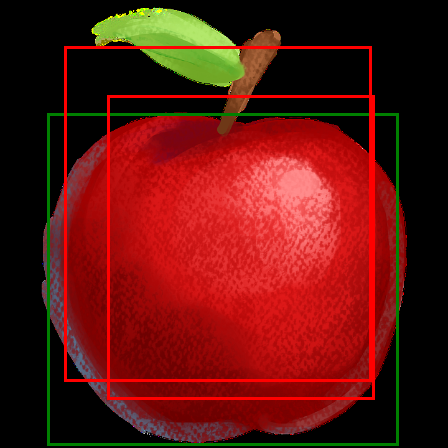

In [32]:
from PIL import ImageDraw

img = torchvision.transforms.ToPILImage()(image)
draw = ImageDraw.Draw(img)

def to_xyxy(box, size=448):
    x, y, width, height = [float(value) for value in box]
    width, height = abs(width), abs(height)

    x1 = max(0, min(size - 1, (x - width / 2) * size))
    y1 = max(0, min(size - 1, (y - height / 2) * size))
    x2 = max(0, min(size - 1, (x + width / 2) * size))
    y2 = max(0, min(size - 1, (y + height / 2) * size))
    return x1, y1, x2, y2


# Ground-truth boxes are green
for elem in targets.reshape(-1, 13):
    if elem[3] > 0.5:
        draw.rectangle(to_xyxy(elem[4:8]), outline="green", width=3)


# Predictions are red. Pick the more confident of the two boxes in each cell.
for elem in preds.reshape(-1, 13):
    confidence_1 = float(elem[3])
    confidence_2 = float(elem[8])
    confidence = max(confidence_1, confidence_2)

    if confidence < 0.25:
        continue

    predicted_box = elem[4:8] if confidence_1 >= confidence_2 else elem[9:13]
    draw.rectangle(to_xyxy(predicted_box), outline="red", width=3)

img
